In [1]:
# =============================================
# Title: Paper Reviews Dataset - Data Cleaning (Colab)
# Description: Clean Paper Reviews dataset from UCI repository with categorical decisions
# =============================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set(style="whitegrid")

In [3]:
# 2. Upload Dataset
uploaded = files.upload()  # Upload your CSV file
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

Saving paper_reviews_dataset.csv to paper_reviews_dataset.csv
Uploaded file: paper_reviews_dataset.csv


In [4]:
# 3. Load Dataset with robust options
df = pd.read_csv(filename, sep=',', engine='python', skipinitialspace=True, header=0)

# Convert 'review' column to string to handle [List] entries
df['review'] = df['review'].astype(str)

# Display initial dataset
print("\nInitial Dataset (first 10 rows):")
display(df.head(10))


Initial Dataset (first 10 rows):


,Name,id,preliminary_decision,review
0,paper,1,accept,[List]
1,paper,2,accept,[List]
2,paper,3,accept,[List]
3,paper,4,accept,[List]
4,paper,5,accept,[List]
5,paper,6,probably reject,[List]
6,paper,7,probably reject,[List]
7,paper,8,accept,[List]
8,paper,9,accept,[List]
9,paper,10,accept,[List]


In [5]:
# 4. Clean Column Names
df.columns = df.columns.str.strip()  # remove leading/trailing spaces
df = df.rename(columns={
    'Name': 'Paper_ID',
    'id': 'Reviewer_ID',
    'preliminary_decision': 'Score',
    'review': 'Review_Text'
})
print("\nRenamed Columns:")
print(df.columns)



Renamed Columns:
Index(['Paper_ID', 'Reviewer_ID', 'Score', 'Review_Text'], dtype='object')


In [6]:
# 5. Map categorical Score to numeric
# accept = 1, probably reject = 0.5, reject = 0
df['Score'] = df['Score'].str.lower().map({
    'accept': 1,
    'probably reject': 0.5,
    'reject': 0
})
print("\nSample after mapping 'Score':")
display(df.head(10))



Sample after mapping 'Score':


,Paper_ID,Reviewer_ID,Score,Review_Text
0,paper,1,1.0,[List]
1,paper,2,1.0,[List]
2,paper,3,1.0,[List]
3,paper,4,1.0,[List]
4,paper,5,1.0,[List]
5,paper,6,0.5,[List]
6,paper,7,0.5,[List]
7,paper,8,1.0,[List]
8,paper,9,1.0,[List]
9,paper,10,1.0,[List]


In [7]:
# 6. Handle Missing Values
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# Drop rows with missing Score, Paper_ID, or Reviewer_ID
df_clean = df.dropna(subset=['Score', 'Paper_ID', 'Reviewer_ID'])
print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())


Missing Values Before Cleaning:
Paper_ID       0
Reviewer_ID    0
Score          2
Review_Text    0
dtype: int64

Missing Values After Cleaning:
Paper_ID       0
Reviewer_ID    0
Score          0
Review_Text    0
dtype: int64


In [8]:
# 7. Handle Inconsistent Values
# Keep only positive reviewer IDs
df_clean = df_clean[df_clean['Reviewer_ID'] > 0]

# Remove rows where Score could not be mapped (NaN)
df_clean = df_clean.dropna(subset=['Score'])

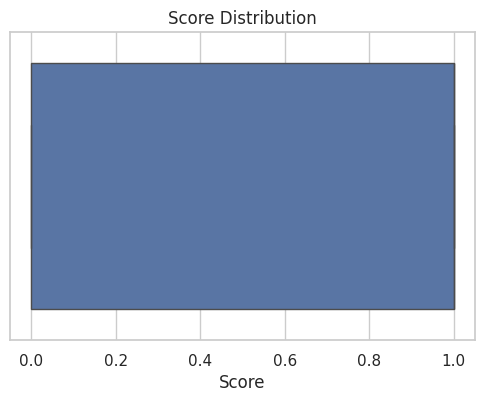

In [9]:
# 8. Detect and Handle Outliers
# Boxplot for Score
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['Score'])
plt.title('Score Distribution')
plt.show()

In [10]:
# 9. Validation Rules
# Paper_ID should be string, Reviewer_ID integer, Score between 0 and 1
assert df_clean['Paper_ID'].dtype == object or df_clean['Paper_ID'].dtype == str, "Paper_ID should be string"
assert df_clean['Reviewer_ID'].dtype in ['int64', 'int32'], "Reviewer_ID should be integer"
assert df_clean['Score'].between(0,1).all(), "Score out of range (0 to 1)"

print("\nAll validation rules passed!")


All validation rules passed!


In [11]:
# 10. Summary of Cleaned Dataset
print("\nCleaned Dataset Info:")
df_clean.info()
print("\nCleaned Dataset Sample:")
display(df_clean.head(10))


Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 170 entries, 0 to 170
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Paper_ID     170 non-null    object 
 1   Reviewer_ID  170 non-null    int64  
 2   Score        170 non-null    float64
 3   Review_Text  170 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.6+ KB

Cleaned Dataset Sample:


,Paper_ID,Reviewer_ID,Score,Review_Text
0,paper,1,1.0,[List]
1,paper,2,1.0,[List]
2,paper,3,1.0,[List]
3,paper,4,1.0,[List]
4,paper,5,1.0,[List]
5,paper,6,0.5,[List]
6,paper,7,0.5,[List]
7,paper,8,1.0,[List]
8,paper,9,1.0,[List]
9,paper,10,1.0,[List]
